# Lab 10：清理一份「網頁語料」

對應講義：[第 10 課](../lessons/10_data.md)

我們沒有真的網頁資料可用（授權與大小都是問題），所以用 3,000 篇 TinyStories 當「好文章」，混進 150 份完全重複、150 份近似重複（改幾個字、加上頁首頁尾）、以及五種常見的垃圾各 60 份（`make_web_corpus`）。因為知道每份文件的真實身分，可以精確量每個步驟抓到什麼、漏了什麼。

1. Gopher 規則（§2.2）
2. 完全重複與 MinHash 近似重複（式 10.1–10.3）
3. 用模型過濾：n-gram 困惑度、hashed n-gram 分類器（§2.4）
4. 整條流水線的結果
5. 污染檢查：TinyStories 的驗證故事有多少和訓練故事重疊（§2.6）

CPU 約 1 分鐘。

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

from lm_course.utils import notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)

In [2]:
from lm_course.artifacts import course_stories
from lm_course.data_pipeline import make_web_corpus

train_stories, val_stories = course_stories()
docs, labels = make_web_corpus(train_stories[:3000], seed=0)
print(f"{len(docs):,} documents:", dict(Counter(labels)))
for kind in ["near duplicate", "junk: spam", "junk: menu", "junk: table", "junk: list", "junk: gibberish"]:
    example = docs[labels.index(kind)]
    print(f"\n--- {kind} ---\n{example[:220]!r}")

3,600 documents: {'clean': 3000, 'exact duplicate': 150, 'junk: spam': 60, 'near duplicate': 150, 'junk: table': 60, 'junk: list': 60, 'junk: gibberish': 60, 'junk: menu': 60}

--- near duplicate ---
'Home | About us | Contact | Privacy policy | Terms of use | Login\nAnna and Ben were very big It was the happy of the big firework show. They put on their warm coats and hats and went very with Mom and Dad. They skipped a'

--- junk: spam ---
'discount best cheap buy buy free online online buy cheap free discount deal discount best best online shoes buy discount shoes price buy online buy free discount online shoes price best shoes discount deal free buy disco'

--- junk: menu ---
'Home | About us | Contact | Privacy policy | Terms of use | Login\nShare this: Facebook Twitter Email Print\nClick here to subscribe to our newsletter!\nCopyright 2024. All rights reserved.\nClick here to subscribe to our ne'

--- junk: table ---
'213 8161 771 5628 7288 2540\n1935 1674 2925 6808 2265 860\n6716 

## 1. Gopher 規則

In [3]:
from lm_course.data_pipeline import gopher_failures

failures = [gopher_failures(d) for d in docs]
table = Counter((label, bool(f)) for label, f in zip(labels, failures))
print(f"{'label':<18} {'removed':>8} {'kept':>6}")
for label in dict.fromkeys(labels):
    print(f"{label:<18} {table[(label, True)]:>8} {table[(label, False)]:>6}")
rules = Counter(rule for label, f in zip(labels, failures) for rule in f if label.startswith("junk"))
print("\nrules that fired on junk:", dict(rules.most_common()))
clean_rules = Counter(rule for label, f in zip(labels, failures) for rule in f if label == "clean")
print("rules that fired on clean stories:", dict(clean_rules.most_common()))

label               removed   kept
clean                     0   3000
exact duplicate           0    150
junk: spam               60      0
near duplicate           34    116
junk: table              60      0
junk: list               60      0
junk: gibberish          60      0
junk: menu               60      0

rules that fired on junk: {'stop words': 248, 'alphabetic words': 143, 'bullet lines': 60, 'duplicate lines': 60, 'word count': 4, 'repeated 2-gram': 1}
rules that fired on clean stories: {}


簡單的規則就擋下了所有垃圾，而且沒有誤殺任何故事（最後一行是空的）。規則也擋下了 34 份近似重複——不是因為它們和別的文件重複，而是加上的頁首和頁尾是同一行導覽列，短故事的行數少，「重複行」的比例就超過了 30% 的門檻。除此之外，規則對**重複**毫無辦法：完全重複的故事每一份單獨看都是好文章，150 份全部過關。

## 2. 去重

### 2.1 完全重複

In [4]:
from lm_course.data_pipeline import exact_duplicates

exact = exact_duplicates(docs)
print(f"exact duplicates found: {len(exact)}  ->", dict(Counter(labels[i] for i in exact)))

exact duplicates found: 150  -> {'exact duplicate': 150}


完全重複的副本多了空白與換行，但正規化（小寫、去標點、合併空白）後雜湊值相同，150 份全部抓到。近似重複一份也抓不到。

### 2.2 MinHash 估計 Jaccard

先看式 (10.2)：取 300 對文件，比較 MinHash（128 個雜湊）估計的相似度與真實的 Jaccard。

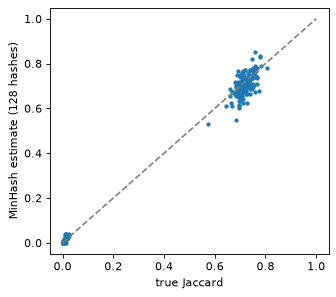

mean absolute error 0.017


In [5]:
from lm_course.data_pipeline import MinHasher, jaccard, minhash_similarity, shingles

hasher = MinHasher(num_perm=128, seed=0)
sets = [shingles(d) for d in docs]
sigs = np.stack([hasher.signature(s) for s in sets])
rng = np.random.default_rng(0)
near_idx = [i for i, lab in enumerate(labels) if lab == "near duplicate"]
pairs = []
for i in near_idx[:150]:  # near duplicate vs its most similar clean story
    j = max(range(3000), key=lambda c: len(sets[i] & sets[c]))
    pairs.append((i, j))
pairs += [tuple(rng.choice(len(docs), 2, replace=False)) for _ in range(150)]
true = [jaccard(sets[i], sets[j]) for i, j in pairs]
est = [minhash_similarity(sigs[i], sigs[j]) for i, j in pairs]
plt.figure(figsize=(4.5, 4))
plt.scatter(true, est, s=8)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("true Jaccard")
plt.ylabel("MinHash estimate (128 hashes)")
plt.show()
print(f"mean absolute error {np.mean(np.abs(np.array(true) - np.array(est))):.3f}")

### 2.3 LSH 的 S 曲線

128 個雜湊切成 $b$ 帶、每帶 $r$ 個（式 10.3）。實線是公式，點是在上面那 300 對文件上實際成為候選的比例（依真實 Jaccard 每 0.1 分一組，只畫至少有 5 對的組）。

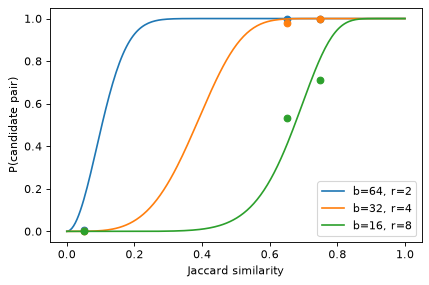

In [6]:
from lm_course.data_pipeline import lsh_candidate_pairs, lsh_candidate_probability

s = np.linspace(0, 1, 200)
plt.figure(figsize=(6, 3.8))
for bands, rows in [(64, 2), (32, 4), (16, 8)]:
    line, = plt.plot(s, lsh_candidate_probability(s, bands, rows), label=f"b={bands}, r={rows}")
    candidates = lsh_candidate_pairs(sigs[[i for p in pairs for i in p]], bands, rows)
    hit = [((2 * k, 2 * k + 1) in candidates) for k in range(len(pairs))]
    bins = np.linspace(0, 1, 11)
    idx = np.digitize(true, bins) - 1
    enough = [b for b in range(10) if np.sum(idx == b) >= 5]  # a bin with 1-2 pairs is mostly noise
    xs = [(bins[b] + bins[b + 1]) / 2 for b in enough]
    ys = [np.mean(np.array(hit)[idx == b]) for b in enough]
    plt.plot(xs, ys, "o", color=line.get_color())
plt.xlabel("Jaccard similarity")
plt.ylabel("P(candidate pair)")
plt.legend()
plt.show()

### 2.4 近似重複：抓到多少、漏掉哪些

1,464 candidate pairs, 298 confirmed, 256 clusters
dropped: {'exact duplicate': 150, 'near duplicate': 105, 'junk: menu': 30}


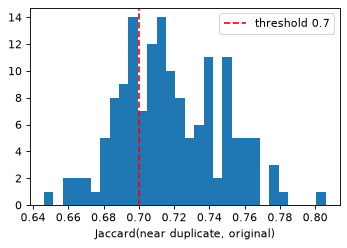

missed 45 near duplicates; their stories are shorter on average: 149 vs 173 words


In [7]:
from lm_course.data_pipeline import near_duplicates

result = near_duplicates(docs, threshold=0.7, num_perm=128, bands=32)
print(f"{result.candidates:,} candidate pairs, {result.confirmed} confirmed, {len(result.clusters)} clusters")
print("dropped:", dict(Counter(labels[i] for i in result.drop)))

near_sims = [jaccard(sets[i], sets[j]) for i, j in pairs[:150]]
plt.figure(figsize=(5, 3.2))
plt.hist(near_sims, bins=30)
plt.axvline(0.7, color="red", ls="--", label="threshold 0.7")
plt.xlabel("Jaccard(near duplicate, original)")
plt.legend()
plt.show()
missed = [i for i in near_idx if i not in set(result.drop)]
print(f"missed {len(missed)} near duplicates; their stories are shorter on average: "
      f"{np.mean([len(docs[i].split()) for i in missed]):.0f} vs {np.mean([len(docs[i].split()) for i in near_idx]):.0f} words")

近似重複的副本改了 3% 的字、又加了兩行頁首頁尾。每改一個字會破壞 5 個 5-gram，頁首頁尾又多出一批新的 shingle——**越短的文件，Jaccard 掉得越多**，所以漏掉的多半是短故事。
另外，「導覽列」類的垃圾彼此也很像（都由同幾行拼成），被當成近似重複聚在一起：去重也順手清掉一部分垃圾。

## 3. 用模型過濾

### 3.1 困惑度過濾（CCNet 的做法）

用**另外 3,000 篇**故事訓練一個 byte-level 的插值 5-gram（第 01 課），替每份文件算 bits-per-byte。

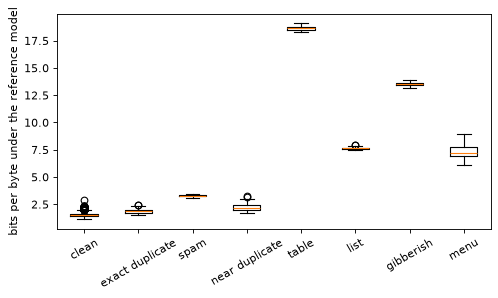

In [8]:
from lm_course.ngram import InterpolatedLM, bits_per_byte, text_to_bytes

reference = InterpolatedLM(5).fit(text_to_bytes("\n".join(train_stories[3000:6000])))
bpb = np.array([bits_per_byte(reference, text_to_bytes(d), start=4) for d in docs])
kinds = list(dict.fromkeys(labels))
plt.figure(figsize=(7, 3.5))
plt.boxplot([bpb[[i for i, lab in enumerate(labels) if lab == k]] for k in kinds], tick_labels=[k.replace("junk: ", "") for k in kinds])
plt.ylabel("bits per byte under the reference model")
plt.xticks(rotation=30)
plt.show()

故事的 bits-per-byte 最低，垃圾明顯較高。數字表格與亂碼甚至遠超過 8（比均勻亂猜還差）：參考模型對下一個位元組「很有把握地猜錯」——故事裡幾乎沒出現過數字與這種字母組合，Witten–Bell 分給沒看過的位元組的機率極小。

### 3.2 hashed n-gram 分類器（DCLM 風格的簡化版）

正例：另外 2,000 篇故事；負例：用**不同亂數種子**另外產生的垃圾。然後替語料打分。

In [9]:
from lm_course.data_pipeline import train_quality_classifier

other_docs, other_labels = make_web_corpus(train_stories[6000:6100], num_exact=0, num_near=0, num_junk_each=200, seed=1)
negatives = [d for d, lab in zip(other_docs, other_labels) if lab.startswith("junk")]
clf = train_quality_classifier(train_stories[6100:8100], negatives, epochs=3)
scores = clf.score(docs)
for k in kinds:
    sel = [i for i, lab in enumerate(labels) if lab == k]
    print(f"{k:<18} mean P(good) = {scores[sel].mean():.3f}   min {scores[sel].min():.3f}")

clean              mean P(good) = 1.000   min 1.000
exact duplicate    mean P(good) = 1.000   min 1.000
junk: spam         mean P(good) = 0.000   min 0.000
near duplicate     mean P(good) = 1.000   min 0.997
junk: table        mean P(good) = 0.008   min 0.002
junk: list         mean P(good) = 0.000   min 0.000
junk: gibberish    mean P(good) = 0.080   min 0.017
junk: menu         mean P(good) = 0.000   min 0.000


兩種模型都能把垃圾和故事分得很開——但要注意，這裡的垃圾很「典型」，而且分類器的負例和語料裡的垃圾是同一個產生器做的；真實世界的低品質文字遠比這難分。

## 4. 整條流水線

In [10]:
keep = np.ones(len(docs), dtype=bool)
steps = [
    ("Gopher rules", np.array([not f for f in failures])),
    ("exact dedup", ~np.isin(np.arange(len(docs)), exact)),
    ("near dedup", ~np.isin(np.arange(len(docs)), result.drop)),
    ("classifier P(good) > 0.5", scores > 0.5),
]
print(f"{'after step':<28}" + "".join(f"{k.replace('junk: ', ''):>12}" for k in kinds))
for name, mask in steps:
    keep &= mask
    counts = Counter(lab for lab, k in zip(labels, keep) if k)
    print(f"{name:<28}" + "".join(f"{counts[k]:>12}" for k in kinds))

after step                         cleanexact duplicate        spamnear duplicate       table        list   gibberish        menu
Gopher rules                        3000         150           0         116           0           0           0           0
exact dedup                         3000           0           0         116           0           0           0           0
near dedup                          3000           0           0          40           0           0           0           0
classifier P(good) > 0.5            3000           0           0          40           0           0           0           0


理想結果是只剩 3,000 篇 clean。剩下的誤差幾乎都是「漏掉的近似重複」——這也是真實資料管線最難的部分。

## 5. 污染：TinyStories 的驗證故事和訓練故事有多像？

用 13-gram 重疊（GPT-3 的方法）檢查 500 篇驗證故事。

In [11]:
from lm_course.data_pipeline import contaminated

sample = val_stories[:500]
for n in (13, 20, 30):
    hits = contaminated(sample, train_stories, n=n)
    print(f"{n}-gram overlap with the training stories: {len(hits) / len(sample):.1%} of validation stories")
i = contaminated(sample, train_stories, n=13)[0]
print("\nexample validation story with an overlap:\n", sample[i][:300])

13-gram overlap with the training stories: 42.2% of validation stories


20-gram overlap with the training stories: 2.8% of validation stories


30-gram overlap with the training stories: 0.2% of validation stories



example validation story with an overlap:
 One day, a little girl named Sue was playing in the park. She saw a big tree with many leaves. Sue wanted to resist climbing the tree but she could not. She started to climb the tree to see how high she could go.
As Sue climbed higher, she felt troubled. She looked down and saw her friend Tom. Tom s


四成多的驗證故事至少和某篇訓練故事共用一段 13 個字的句子，門檻拉到 20 個字就只剩約 3%——不是資料外洩，而是**合成資料的特性**：GPT 生成的幼兒故事用字與句型高度重複（「Once upon a time, there was a little girl named Lily.」）。
這提醒我們：(1) 驗證 loss 會偏樂觀；(2) n-gram 重疊的門檻要依資料的性質選。

## 小結

- 規則便宜又有效，但只能抓「一眼就是垃圾」的東西。
- 去重分兩層：雜湊抓完全重複，MinHash＋LSH 在次線性的成本下抓近似重複；短文件的近似重複最難抓。
- 模型過濾（困惑度、分類器）能抓規則抓不到的東西，但會把「正例的風格」當成品質。

下一步：[第 11 課](../lessons/11_sft_and_chat.md)——讓預訓練好的模型學會對話。